<a href="https://colab.research.google.com/github/P-Karthikeya512/Rock-segmentation/blob/main/Skip_connections_modified1_UNET%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 50
SEED = 42

IMAGE_DIR = "/content/drive/MyDrive/dataset_rock/images"
MASK_DIR  = "/content/drive/MyDrive/dataset_rock/masks"

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

print("Images :", len(os.listdir(IMAGE_DIR)))
print("Masks  :", len(os.listdir(MASK_DIR)))

# =========================
# PAIR IMAGES WITH MASKS
# =========================
def get_pairs(image_dir, mask_dir):
    image_paths = []
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        image_paths.extend(glob.glob(os.path.join(image_dir, f"*.{ext}")))

    image_paths = sorted(image_paths)

    mask_map = {}
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        for p in glob.glob(os.path.join(mask_dir, f"*.{ext}")):
            stem = os.path.splitext(os.path.basename(p))[0]
            mask_map[stem] = p

    pairs = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        if stem in mask_map:
            pairs.append((img_path, mask_map[stem]))
        else:
            print(f"Warning: no mask found for {img_path}")

    return pairs

pairs = get_pairs(IMAGE_DIR, MASK_DIR)
print("Total paired samples:", len(pairs))

Images : 16
Masks  : 16
Total paired samples: 16


In [5]:
# =========================
# LOAD IMAGE + MASK
# =========================
def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path.decode(), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.numpy_function(
        func=load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img, mask

# =========================
# DATASET
# =========================
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED
)

def duplicate_mask(image, mask):
    return image, (mask, mask, mask, mask)

def make_dataset(pairs, training=True, duplicate=False):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=AUTOTUNE)

    if duplicate:
        ds = ds.map(duplicate_mask, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_multi = make_dataset(train_pairs, training=True, duplicate=True)
val_ds_multi   = make_dataset(val_pairs, training=False, duplicate=True)

train_ds_single = make_dataset(train_pairs, training=True, duplicate=False)
val_ds_single   = make_dataset(val_pairs, training=False, duplicate=False)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

Train samples: 12
Val samples: 4


Model: "UNetPlusPlus_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 256, 256,  │          0 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 256, 256,  │      9,248 │ re_lu_30[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 256, 256,  │          0 │ conv2d_31[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ re_lu_31[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 128, 128,  │          0 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │     36,928 │ re_lu_32[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 128, 128,  │          0 │ conv2d_33[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ re_lu_33[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_34 (ReLU)     │ (None, 64, 64,    │          0 │ conv2d_34[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │    147,584 │ re_lu_34[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_35 (ReLU)     │ (None, 64, 64,    │          0 │ conv2d_35[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ re_lu_35[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_6[

 Total params: 9,408,068 (35.89 MB)

 Trainable params: 9,408,068 (35.89 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 256, 256,  │          0 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 256, 256,  │      9,248 │ re_lu_30[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 256, 256,  │          0 │ conv2d_31[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ re_lu_31[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 128, 128,  │          0 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │     36,928 │ re_lu_32[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 128, 128,  │          0 │ conv2d_33[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ re_lu_33[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_34 (ReLU)     │ (None, 64, 64,    │          0 │ conv2d_34[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │    147,584 │ re_lu_34[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_35 (ReLU)     │ (None, 64, 64,    │          0 │ conv2d_35[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ re_lu_35[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_6[

 Total params: 9,408,068 (35.89 MB)

 Trainable params: 9,408,068 (35.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 0.8059 - side_1_accuracy: 0.3380 - side_1_dice_coef: 0.4802 - side_1_iou_coef: 0.3168 - side_1_loss: 0.9299 - side_2_accuracy: 0.5420 - side_2_dice_coef: 0.5895 - side_2_iou_coef: 0.4192 - side_2_loss: 0.7473 - side_3_accuracy: 0.4501 - side_3_dice_coef: 0.5580 - side_3_iou_coef: 0.3877 - side_3_loss: 0.7964 - side_4_accuracy: 0.5469 - side_4_dice_coef: 0.5894 - side_4_iou_coef: 0.4189 - side_4_loss: 0.7499
val_avg_loss=0.7211  val_avg_accuracy=0.5622  val_avg_dice_coef=0.6121  val_avg_iou_coef=0.4410

Epoch 1: val_avg_dice_coef improved from None to 0.61210, saving model to best_unetpp_paper.keras

Epoch 1: finished saving model to best_unetpp_paper.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - loss: 0.7762 - side_1_accuracy: 0.3472 - side_1_dice_coef: 0.5003 - side_1_iou_coef: 0.3343 - side_1_loss: 0.8947 - side_2_accuracy: 0.5974 - side_2_dice_coef: 0.6124 - side_2_iou_coef: 0.4426 - side_2_loss: 0.7151 - side_3_accuracy: 0.52

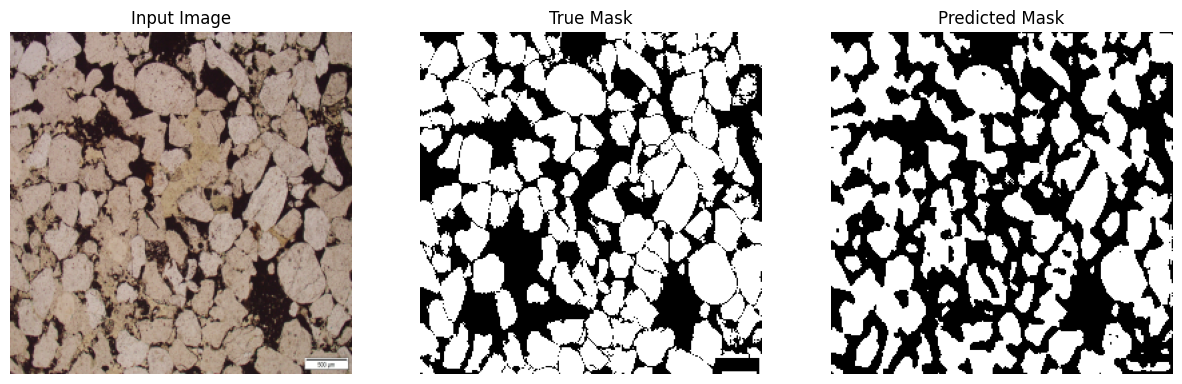

In [6]:
# =========================
# LOSS + METRICS
# =========================
bce_loss_fn = tf.keras.losses.BinaryCrossentropy()

def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def combined_bce_dice_loss(y_true, y_pred):
    bce = bce_loss_fn(y_true, y_pred)
    dloss = dice_loss(y_true, y_pred)
    return 0.5 * bce + dloss

def iou_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# =========================
# UNET++ BLOCKS
# =========================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.ReLU()(x)
    return x

# =========================
# BUILD UNET++ WITH YOUR EXTRA DIRECT SKIPS
# =========================
def build_unet_plus_plus(input_shape=(256, 256, 3)):
    filters = [32, 64, 128, 256, 512]
    depth = len(filters) - 1

    inputs = layers.Input(shape=input_shape)
    X = {}

    # Encoder backbone
    x = inputs
    for i in range(depth + 1):
        X[(i, 0)] = conv_block(x, filters[i])
        if i < depth:
            x = layers.MaxPooling2D((2, 2))(X[(i, 0)])

    # Nested decoder / skip pathways
    for j in range(1, depth + 1):
        for i in range(0, depth - j + 1):
            up = layers.Conv2DTranspose(
                filters[i],
                kernel_size=2,
                strides=2,
                padding="same"
            )(X[(i + 1, j - 1)])

            concat_inputs = [X[(i, k)] for k in range(j)] + [up]

            # Your extra direct skips:
            # X(1,0) -> X(0,4)
            # X(2,0) -> X(1,3)
            # X(3,0) -> X(2,2)
            direct_skip_map = {
                (0, 4): (1, 0),
                (1, 3): (2, 0),
                (2, 2): (3, 0),
            }

            if (i, j) in direct_skip_map:
                si, sj = direct_skip_map[(i, j)]
                direct_up = layers.Conv2DTranspose(
                    filters[i],
                    kernel_size=2,
                    strides=2,
                    padding="same"
                )(X[(si, sj)])
                concat_inputs.append(direct_up)

            x = layers.Concatenate()(concat_inputs)
            X[(i, j)] = conv_block(x, filters[i])

    # Deep supervision outputs
    side_outputs = [
        layers.Conv2D(1, 1, activation="sigmoid", name=f"side_{j}")(X[(0, j)])
        for j in range(1, depth + 1)
    ]

    # Training model returns all 4 side outputs
    train_model = Model(inputs, side_outputs, name="UNetPlusPlus_Train")

    # Accurate inference mode: average the 4 outputs
    avg_output = layers.Average(name="avg_output")(side_outputs)
    infer_model = Model(inputs, avg_output, name="UNetPlusPlus_Infer")

    return train_model, infer_model

train_model, infer_model = build_unet_plus_plus()

train_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=[combined_bce_dice_loss for _ in range(4)],
    loss_weights=[0.25, 0.25, 0.25, 0.25],
    metrics=[
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
    ]
)

infer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=combined_bce_dice_loss,
    metrics=[
        "accuracy",
        dice_coef,
        iou_coef
    ]
)

train_model.summary()
infer_model.summary()

# =========================
# CALLBACK TO EVALUATE AVERAGED OUTPUT
# =========================
class EvaluateAveragedModel(tf.keras.callbacks.Callback):

    def __init__(self, averaged_model, val_ds):
        super().__init__()
        self.averaged_model = averaged_model
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):

        logs = logs if logs is not None else {}

        results = self.averaged_model.evaluate(
            self.val_ds,
            verbose=0,
            return_dict=True
        )

        logs["val_avg_loss"] = float(results["loss"])
        logs["val_avg_accuracy"] = float(results["accuracy"])
        logs["val_avg_dice_coef"] = float(results["dice_coef"])
        logs["val_avg_iou_coef"] = float(results["iou_coef"])

        print(
            f"\n"
            f"val_avg_loss={logs['val_avg_loss']:.4f}  "
            f"val_avg_accuracy={logs['val_avg_accuracy']:.4f}  "
            f"val_avg_dice_coef={logs['val_avg_dice_coef']:.4f}  "
            f"val_avg_iou_coef={logs['val_avg_iou_coef']:.4f}"
        )

paper_eval_cb = EvaluateAveragedModel(infer_model, val_ds_single)

callbacks = [

    paper_eval_cb,

    tf.keras.callbacks.ModelCheckpoint(
        "best_unetpp_paper.keras",
        monitor="val_avg_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_avg_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )

]

# =========================
# TRAIN
# =========================
history = train_model.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=EPOCHS,
    callbacks=callbacks
)

# =========================
# PLOTS
# =========================
def plot_training_curves(history):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(20,5))

    # ---------------- Accuracy ----------------

    plt.subplot(1,4,1)
    if "side_4_accuracy" in hist:
        plt.plot(
            epochs_range,
            hist["side_4_accuracy"],
            label="Train Accuracy"
        )
    if "val_avg_accuracy" in hist:
        plt.plot(
            epochs_range,
            hist["val_avg_accuracy"],
            label="Validation Accuracy"
        )
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # ---------------- Dice ----------------

    plt.subplot(1,4,2)
    if "side_4_dice_coef" in hist:
        plt.plot(
            epochs_range,
            hist["side_4_dice_coef"],
            label="Train Dice"
        )
    if "val_avg_dice_coef" in hist:
        plt.plot(
            epochs_range,
            hist["val_avg_dice_coef"],
            label="Validation Dice"
        )
    plt.title("Dice Coefficient")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)

    # ---------------- IoU ----------------
    plt.subplot(1,4,3)
    if "side_4_iou_coef" in hist:
        plt.plot(
            epochs_range,
            hist["side_4_iou_coef"],
            label="Train IoU"
        )
    if "val_avg_iou_coef" in hist:
        plt.plot(
            epochs_range,
            hist["val_avg_iou_coef"],
            label="Validation IoU"
        )
    plt.title("IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    # ---------------- Loss ----------------
    plt.subplot(1,4,4)
    plt.plot(
        epochs_range,
        hist["loss"],
        label="Train Loss"
    )
    if "val_avg_loss" in hist:
        plt.plot(
            epochs_range,
            hist["val_avg_loss"],
            label="Validation Loss"
        )
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================
# PREDICTION + VISUALIZATION
# =========================
def show_prediction(model, pair):
    img_path, mask_path = pair
    img, mask = load_image_mask(img_path.encode(), mask_path.encode())

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

show_prediction(infer_model, val_pairs[0])

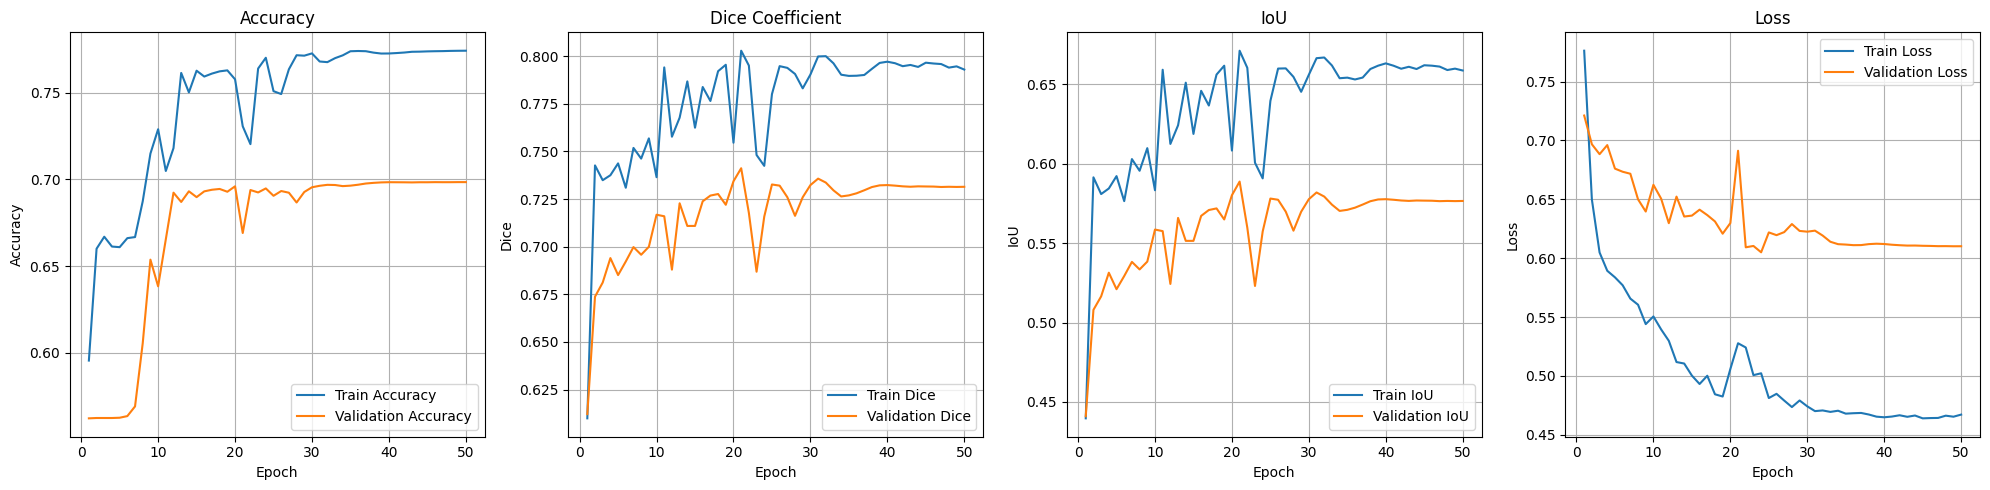

In [7]:
plot_training_curves(history)
